In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [1]:
import pandas as pd
import numpy as np
import sys # 최대정수
from tensorflow.keras.utils import to_categorical # 분류분석시 y데이터 원핫인코딩
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split # 데이터 분리

# 이진분류(로지스틱 회귀분석)
- 1. 데이터셋 생성 & 전처리
    * 엑셀 -> 데이터프레임 -> ?처리(결측치로 전환하여 결측치처리) -> x,y 분리
    - > x 변수의 scale 조정 -> train_test_split()이용하여 학습셋과 테스트셋분리
- 2. 모델생성(입력16, 출력1) & 학습과정 설정 & 학습
- 3. 모델 평가하기(그래프, 평가, 혼동행렬==교차표)
- 4. 모델 사용

In [ ]:
'''
age 나이 (세)
sex 성별
    1 : 남성
    0 : 여성
cp (chest pain type) 가슴 통증(흉통) 타입
    1 : typical angina (전형적 협심증)
    2 : atypical angina (비전형적 협심증)
    3 : non-anginal pain (심장 관련이 아닌 흉통)
    4 : asymptomatic (증상 없음)
treshtbps (resting blood pressure) 안정 시 수축기 혈압 (mm Hg)
    병원 처음 내원했을 때 잰 혈압이라고 보면 됨
chol (serum cholesterol) 혈청 콜레스테롤 수치 (mg/dl)
    여기 보니까 ?가 있어서, 일부 결측값이 문자로 들어가 있는 상태야
fbs (fasting blood sugar) 공복 혈당 > 120 mg/dl 여부
    1 : 공복 혈당 120 초과 (고혈당)
    0 : 아니면 0
restecg (resting electrocardiographic results) 안정시 심전도 결과
    0 : 정상
    1 : ST-T wave 이상 (ST-T 파 이상, T wave 반전 등)
    2 : LVH 가능성 (좌심실 비대 소견 등)
thalach (maximum heart rate achieved) 운동 검사에서 기록된 최대 심박수
exang (exercise induced angina) 운동으로 유발된 협심증 여부
    1 : 운동 시 흉통 있음
    0 : 없음
oldpeak 운동으로 인해 발생한 ST 절 하강 정도 (depression)
    숫자가 클수록 보통 심장 허혈 가능성↑로 봄
slope (slope of peak exercise ST segment) 운동 시 ST 세그먼트 기울기
    1 : upsloping (상승형)
    2 : flat (평평)
    3 : downsloping (하강형)
ca 조영제(조영술)에서 보이는 주요 관상동맥 수 (0~3)
    0이면 문제 있는 관상동맥이 없는 것, 
    숫자가 클수록 문제 있는 혈관 수가 많다고 보면 됨
    여기에도 ? 값 좀 섞여 있음
hsl (보통 다른 데이터셋에서는 thal) 아마 **thalassemia 관련 검사 결과(thal)**를 의미
    3 : normal
    6 : fixed defect (고정 결손)
    7 : reversible defect (가역 결손)
    여기도 숫자가 이런 패턴이라, 같은 의미로 봐도 될 듯
heartDisease (target) 심장질환 유무 (목표 변수)
'''

## 1. 데이터셋 생성 & 전처리
* 엑셀 -> 데이터프레임 -> ?처리(결측치로 전환하여 결측치처리) -> x,y 분리
  - > x 변수의 scale 조정 -> train_test_split()이용하여 학습셋과 테스트셋분리

In [6]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [8]:
# 아나콘다 프롬프트에서 ml-dl-nlp 가상환경(conda activate ml-dl-nlp)으로 간 후
# pip install openpyxl

In [2]:
df = pd.read_excel('data/heart-disease.xlsx', sheet_name='processed.cleveland') # openpyxl 모듈이 설치되어야 사용가능
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   treshtbps     303 non-null    int64  
 4   chol          303 non-null    object 
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   thalach       303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            303 non-null    object 
 12  hsl           303 non-null    object 
 13  heartDisease  303 non-null    int64  
dtypes: float64(1), int64(10), object(3)
memory usage: 33.3+ KB


In [3]:
df.isin(['?']).sum()

age             0
sex             0
cp              0
treshtbps       0
chol            1
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              4
hsl             2
heartDisease    0
dtype: int64

In [4]:
# '?'가 포함된 데이터 추출(chol, ca, hsl) : 7 행
df[(df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?')]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
87,53,0,3,128,216,0,2,115,0,0.0,1,0,?,0
166,52,1,3,138,223,0,0,169,0,0.0,1,?,3,0
192,43,1,4,132,247,1,2,143,1,0.1,2,?,7,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0,?,1
287,58,1,2,125,220,0,0,144,0,0.4,2,?,7,0
302,38,1,3,138,175,0,0,173,0,0.0,1,?,3,0


In [5]:
# ?를 결측치로(np.nan)로 대체 -> 결측치 처리(삭제)
df.replace('?', np.nan, inplace= True)
df[(df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?')]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [6]:
# 결측치가 포함된 데이터 추출
df[df.isnull().any(axis=1)]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,NaN,0,2,129,1,2.6,2,2.0,7.0,1
87,53,0,3,128,216.0,0,2,115,0,0.0,1,0.0,NaN,0
166,52,1,3,138,223.0,0,0,169,0,0.0,1,NaN,3.0,0
192,43,1,4,132,247.0,1,2,143,1,0.1,2,NaN,7.0,1
266,52,1,4,128,204.0,1,0,156,1,1.0,2,0.0,NaN,1
287,58,1,2,125,220.0,0,0,144,0,0.4,2,NaN,7.0,0
302,38,1,3,138,175.0,0,0,173,0,0.0,1,NaN,3.0,0


In [7]:
# 결측치 처리: 대체(fillna) 삭제(dropna)
df.dropna(how='any',   # 결측치가 한열이라도 있으면 삭제
          inplace=True) 

In [8]:
df.isna().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [9]:
# target 변수의 분포가 균형을 이루는지
df['heartDisease'].value_counts() / df.shape[0]

0    0.540541
1    0.459459
Name: heartDisease, dtype: float64

In [10]:
# 입력(독립)변수와 종속(타겟, 출력)변수 분리
X = df.iloc[:,:-1].values # 마지막열을 제외한 부분을 numpy 배열
y = df.iloc[:,-1:].values # 2차원 numpy 배열(train_text_split 사용)
X.shape, y.shape

((296, 13), (296, 1))

In [11]:
X[0]

array([ 63. ,   1. ,   1. , 145. , 233. ,   1. ,   2. , 150. ,   0. ,
         2.3,   3. ,   0. ,   6. ])

In [12]:
# 입력변수 X의 스케일 조정
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)
scaled_X

array([[ 0.94228535,  0.69282032, -2.23679346, ...,  2.26408737,
        -0.71842092,  0.66026226],
       [ 1.38571375,  0.69282032,  0.87648647, ...,  0.64531959,
         2.48739704, -0.89083003],
       [-1.93999926,  0.69282032, -0.16127351, ...,  2.26408737,
        -0.71842092, -0.89083003],
       ...,
       [ 1.49657085,  0.69282032,  0.87648647, ...,  0.64531959,
         1.41879105,  1.17729303],
       [ 0.27714275,  0.69282032,  0.87648647, ...,  0.64531959,
         0.35018507,  1.17729303],
       [ 0.27714275, -1.44337567, -1.19903349, ...,  0.64531959,
         0.35018507, -0.89083003]])

In [13]:
scaler = MinMaxScaler()
scaled_X = scaler.fit_transform(X)
scaled_X

array([[0.70833333, 1.        , 0.        , ..., 1.        , 0.        ,
        0.75      ],
       [0.79166667, 1.        , 1.        , ..., 0.5       , 1.        ,
        0.        ],
       [0.16666667, 1.        , 0.66666667, ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.8125    , 1.        , 1.        , ..., 0.5       , 0.66666667,
        1.        ],
       [0.58333333, 1.        , 1.        , ..., 0.5       , 0.33333333,
        1.        ],
       [0.58333333, 0.        , 0.33333333, ..., 0.5       , 0.33333333,
        0.        ]])

In [14]:
# scaled_X,y 를 학습셋: 테스트셋 = 7:3 으로 분할
X_train, X_test, y_train, y_test = train_test_split(scaled_X,
                                                    y,
                                                    test_size=0.3, #테스트셋의 비율
                                                    random_state=7,
                                                    stratify=y) # 층화추출

In [15]:
# 심장병 음성/양성의 비율
print(pd.DataFrame(y).value_counts(normalize=True))
print(pd.DataFrame(y_train).value_counts(normalize=True))
print(pd.DataFrame(y_test).value_counts(normalize=True))

0    0.540541
1    0.459459
dtype: float64
0    0.541063
1    0.458937
dtype: float64
0    0.539326
1    0.460674
dtype: float64


## 2. 모델생성(입력13, 출력1) & 학습과정 설정 & 학습
- 모델 16 -> 32 -> 16 -> 8 ->1
- 그래프를 보고, 과적합 줄이기 추가할 수 있음

In [16]:
from tensorflow.keras.layers import Dropout
model = Sequential()
model.add(Dense(units=32, input_dim=13, activation='tanh'))
model.add(Dropout(0.3))
model.add(Dense(units=16, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=8, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(units=1,activation='sigmoid'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                448       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense_2 (Dense)             (None, 8)                 136       
                                                                 
 dropout_2 (Dropout)         (None, 8)                 0         
                                                                 
 dense_3 (Dense)             (None, 1)                 9

In [17]:
# from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, Precision
model.compile(loss='binary_crossentropy',
             optimizer='adam',
             metrics=['accuracy', # 정확도
                     Precision(), # 정밀도(예측값 중심)
                     Recall()])   # 재현율(실제값 중심)

In [18]:
%%time
hist = model.fit(X_train, y_train, # 훈련데이터셋
                epochs=200,            #  학습횟수
                validation_split=0.2,  # 검증데이터를 훈련데이터의 20%로 사용
                verbose=0) # 로그출력 안함

CPU times: total: 7.33 s
Wall time: 6.33 s


## 3. 모델평가(그래프, 평가, 교차표)

In [20]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'precision', 'recall', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall'])

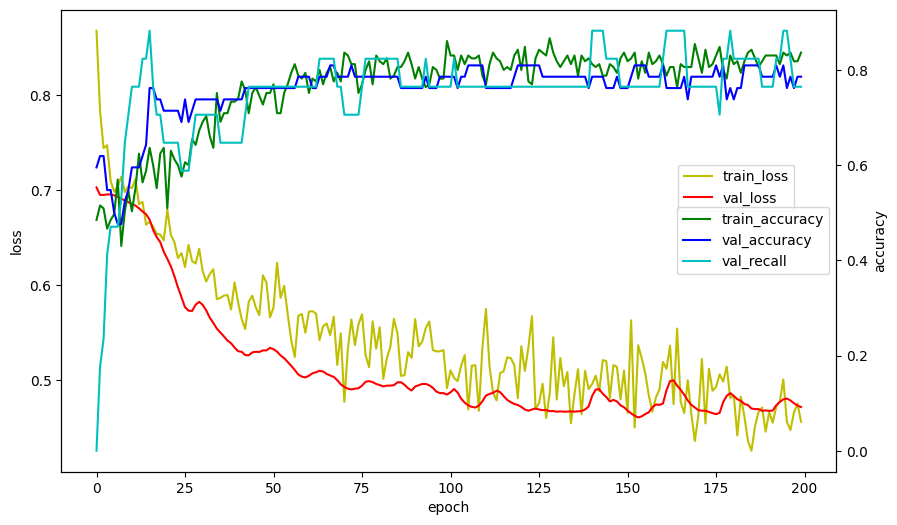

In [22]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
acc_ax.plot(hist.history['val_recall'],'c',label='val_recall')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(bbox_to_anchor=(0.955,0.68))
acc_ax.legend(loc= 'center right')
plt.show()

In [23]:
score = model.evaluate(X_train, y_train, verbose=0)
print('model loss : ', score[0])
print('model accuracy : ', score[1])
print('model precision : ', score[2])
print('model recall : ', score[3])

model loss :  0.4231131076812744
model accuracy :  0.8454106450080872
model precision :  0.8315789699554443
model recall :  0.8315789699554443


In [ ]:
# 교차표(혼동행렬)

In [27]:
y_hat = (model.predict(X_test) >= 0.5).astype(int)
y_test.shape, y_hat.shape

3/3 [==============================] - 0s 2ms/step


((89, 1), (89, 1))

In [28]:
TN =0; FP=0; FN=0; TP=0;
for y, h in zip(y_test, y_hat.reshape(-1)):
    if y==0 and h==0:
        TN += 1
    elif y==0 and h==1:
        FP += 1
    elif y==1 and h==0:
        FN += 1
    else:
        TP += 1
print(TN, FP)
print(FN, TP)

38 10
6 35


In [32]:
ctab = pd.crosstab(y_test.reshape(-1), y_hat.reshape(-1))
ctab.index.name = '실제값'
ctab.columns.name = '예측값'
ctab

예측값,0,1
실제값,,
0,38,10
1,6,35


In [34]:
confusion_matrix(y_test, y_hat)

array([[38, 10],
       [ 6, 35]], dtype=int64)

In [ ]:
# 모델 사용

In [35]:
X_test[0]

array([0.58333333, 1.        , 1.        , 0.52830189, 0.34246575,
       0.        , 1.        , 0.3129771 , 1.        , 0.09677419,
       0.5       , 0.33333333, 0.75      ])

In [38]:
model.predict([[0.58333333, 1.        , 1.        , 0.52830189, 0.34246575,
       0.        , 1.        , 0.3129771 , 1.        , 0.09677419,
       0.5       , 0.33333333, 0.75      ]], verbose=0)

array([[0.6577036]], dtype=float32)

In [40]:
from tensorflow.keras.models import save_model, load_model
save_model(model, 'model/07binary.h5')

# 분류분석
- X_train, y_train, x_test, y_test를 사용
-> y_train과 y_test 원핫인코딩

In [16]:
X_train.shape

(207, 13)

In [17]:
# y_train, y_test 원핫인코딩
Y_train = to_categorical(y_train)
Y_test = to_categorical(y_test)
Y_train.shape, Y_test.shape

((207, 2), (89, 2))

In [34]:
# 모델생성
model2 = Sequential()
model2.add(Dense(units=32,
                input_shape=(13,),
                activation="relu"))
model2.add(Dense(units=16,
                activation='relu'))
model2.add(Dense(units=2,
                activation='softmax'))
model2.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 32)                448       
                                                                 
 dense_10 (Dense)            (None, 16)                528       
                                                                 
 dense_11 (Dense)            (None, 2)                 34        
                                                                 
Total params: 1,010
Trainable params: 1,010
Non-trainable params: 0
_________________________________________________________________


In [35]:
# 학습과정 설정
model2.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy'])

In [27]:
Y_train.shape, X_train.shape

((207, 2), (207, 13))

In [37]:
# 모델학습
hist2 = model2.fit(X_train, Y_train,
                  epochs=200,
                  validation_split=0.2,
                  verbose=0
                  )

In [39]:
pred = model2.predict(X_test[0].reshape(-1,13))
pred.argmax(axis=1)

1/1 [==============================] - 0s 65ms/step


array([1], dtype=int64)